In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from os import mkdir, listdir, walk
from os.path import join, exists, getsize

In [8]:
date = "20260502"
ref = pd.read_csv(join("..", "..",  "results", "ref", f"_ref_files_{date}.csv.gz"))

C:\Users\pichenotf\AppData\Local\Temp\ipykernel_3948\2534714304.py:2: DtypeWarning: Columns (11,12,13,14,16,17,18,19,24,25,26,27,30,31,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  ref = pd.read_csv(join("..", "..",  "results", "ref", f"_ref_files_{date}.csv.gz"))


In [10]:
p = ref[ref['corpus_code'].str.contains('PRA')]
p = p[p['file_type'].isin(['tiff','ocr xml'])]

In [11]:
pd.pivot_table(p, index='corpus_code', columns='file_type', values=['size'], aggfunc={'size': 'sum'}, margins=True) / 1024 ** 4

size          
file_type        tiff       All
corpus_code                    
PRA_AVE      0.640969  0.640969
PRA_BDR      0.009252  0.009252
PRA_CRT      0.869929  0.869929
PRA_CTG      0.039706  0.039706
PRA_ERT      2.624503  2.624503
PRA_IND      0.166929  0.166929
PRA_JRX      3.940213  3.940213
PRA_RTG      0.016221  0.016221
All          8.307722  8.307722

In [12]:
ref['file_type'].value_counts()

file_type
jpeg        673674
tiff        620516
autre       422049
pdf         338162
ocr txt     334782
ocr xml      33312
audio         7347
video          465
jpeg2000        20
Name: count, dtype: int64

In [13]:
t = p[p['file_type'] == 'tiff']
t['resolution'] = t['mix_imageHeight'] * t['mix_imageWidth']
res = pd.pivot_table(t, index='corpus_code', values=['uuid', 'resolution', 'mix_imageWidth', 'mix_imageHeight', 'size'],
                     aggfunc={'uuid':'count',
                              'resolution':'median', 
                              'mix_imageWidth':'median',
                              'mix_imageHeight':'median',
                              'size': 'median'}).reset_index()
res['size'] = res['size'] / 1024 ** 2
res.columns = ['collection_det', 'hauteur (médiane)', 'largeur (médiane)', 'résolution (médiane)', 'poids (médiane)', 'nb fichiers']
res

,collection_det,hauteur (médiane),largeur (médiane),résolution (médiane),poids (médiane),nb fichiers
0,PRA_AVE,4363.0,3252.0,14092002.0,12.780376,44275
1,PRA_BDR,5254.0,3322.0,17445376.0,16.637550,583
2,PRA_CRT,6667.0,4990.0,33268330.0,31.653373,29202
3,PRA_CTG,4817.5,3711.0,17825331.5,11.011528,1438
4,PRA_ERT,6354.0,4961.0,31147776.0,28.699898,94386
5,PRA_IND,4803.0,3477.0,16720752.0,10.658604,16358
6,PRA_JRX,6343.0,5149.0,32578452.0,28.257835,149171
7,PRA_RTG,5142.5,4075.0,20979893.0,20.015018,848


In [14]:
ax = t[['mix_imageWidth', 'corpus_code']].boxplot(by='corpus_code', showfliers=False, vert=False)
plt.show()

KeyError: "['collection_det'] not in index"

In [17]:
ref.groupby(['file_type', 'extension'])['uuid'].count()

file_type  extension
audio      .mp3            572
           .wav           6775
autre      .BUP              7
           .DS_Store         7
           .IFO              8
           .MSWMM            2
           .VOB             15
           .bmp              6
           .css              3
           .dat              1
           .doc              9
           .docx             8
           .html          2180
           .ini              4
           .ion              1
           .js              16
           .ods              2
           .png             79
           .rtf              4
           .url              1
           .webp            22
           .xcf             38
           .xls             20
           .xlsx            13
           .xml         419596
           .zip              7
jpeg       .JPG         222572
           .jpeg           454
           .jpg         450648
jpeg2000   .jp2             20
ocr txt    .txt         334782
ocr xml    .alto  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from os import mkdir, listdir, walk
from os.path import join, exists, getsize
import shutil
import pyvips
from sklearn.preprocessing import StandardScaler

In [9]:
result_folder = "D:\\bnr-image-resize\\img"

In [10]:
def get_file_racine(filename):
    if filename:
        filebase = Path(filename).stem
        pattern = '^RBX_([a-zA-Z0-9]+_[a-zA-Z0-9]+)_[a-zA-Z0-9]+'
        a = re.search(pattern, filebase)
        if a:
            racine = a.group(1)
        else:
            pattern = '^([a-zA-Z0-9]+_[a-zA-Z0-9]+)_[a-zA-Z0-9]+'
            a = re.search(pattern, filebase)
            if a:
                racine = a.group(1)
            else:
                racine = 'INCONNU1'
    else:
        racine = 'INCONNU0'
    return racine

In [11]:
df = pd.read_csv("../_ref/_ref_files_20250906.csv.gz")

C:\Users\pichenotf\AppData\Local\Temp\ipykernel_940\2136706608.py:1: DtypeWarning: Columns (11,13,14,15,16,17,19,20,21,22,27,28,29,30,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../_ref/_ref_files_20250906.csv.gz")


In [12]:
df.columns

Index(['name', 'path', 'size', 'last_content_modification_date',
       'last_metadata_modification_date', 'checksum_md5', 'uuid', 'extension',
       'file_type', 'source2s3', 'conservation_statut', 's3_uploaded_date',
       's3_uploaded', 's3_key', 'finding_aid', 'unitid', 'osiros_id',
       'mix_objectIdentifierValue', 'mix_fileSize', 'mix_dateTimeCreated',
       'mix_formatName', 'mix_byteOrder', 'mix_compressionScheme',
       'mix_imageWidth', 'mix_imageHeight', 'mix_xSamplingFrequency',
       'mix_ySamplingFrequency', 'mix_samplingFrequencyUnit', 'mix_colorSpace',
       'mix_scanningSoftwareName', 'mix_formatVersion', 'publication_statut',
       'collection_code', 'oai_set', 'collection', 'nb'],
      dtype='object')

# On ne conserve que les tiff et alto

In [13]:
p = df[df['name'].str.contains('PRA')]
p = p[p['file_type'].isin(['tiff','ocr xml'])]

In [16]:
p['collection_det'] = p['name'].apply(get_file_racine)

In [18]:
pd.pivot_table(p, index='collection_det', columns='file_type', values=['size'], aggfunc={'size': 'sum'}, margins=True) / 1024 ** 4

size                    
file_type        ocr xml      tiff       All
collection_det                              
PRA_AVE         0.044086  0.640969  0.685055
PRA_BDR         0.000313  0.009252  0.009564
PRA_CRT         0.035558  0.869929  0.905486
PRA_CTG         0.001242  0.039706  0.040948
PRA_ERT         0.119237  2.624503  2.743740
PRA_IND         0.010906  0.166929  0.177835
PRA_JRX         0.206208  3.940213  4.146421
PRA_RTG         0.000982  0.016221  0.017203
All             0.418531  8.307722  8.726253

In [19]:
t = p[p['file_type'] == 'tiff']
t['resolution'] = t['mix_imageHeight'] * t['mix_imageWidth']
res = pd.pivot_table(t, index='collection_det', values=['uuid', 'resolution', 'mix_imageWidth', 'mix_imageHeight', 'size'],
                     aggfunc={'uuid':'count',
                              'resolution':'median', 
                              'mix_imageWidth':'median',
                              'mix_imageHeight':'median',
                              'size': 'median'}).reset_index()
res['size'] = res['size'] / 1024 ** 2
res.columns = ['collection_det', 'hauteur (médiane)', 'largeur (médiane)', 'résolution (médiane)', 'poids (médiane)', 'nb fichiers']
res

C:\Users\pichenotf\AppData\Local\Temp\ipykernel_940\1654260976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t['resolution'] = t['mix_imageHeight'] * t['mix_imageWidth']


,collection_det,hauteur (médiane),largeur (médiane),résolution (médiane),poids (médiane),nb fichiers
0,PRA_AVE,4363.0,3252.0,14092002.0,12.780376,44275
1,PRA_BDR,5254.0,3322.0,17445376.0,16.637550,583
2,PRA_CRT,6667.0,4990.0,33268330.0,31.653373,29202
3,PRA_CTG,4817.5,3711.0,17825331.5,11.011528,1438
4,PRA_ERT,6354.0,4961.0,31147776.0,28.699898,94386
5,PRA_IND,4803.0,3477.0,16720752.0,10.658604,16358
6,PRA_JRX,6343.0,5149.0,32578452.0,28.257835,149171
7,PRA_RTG,5142.5,4075.0,20979893.0,20.015018,848


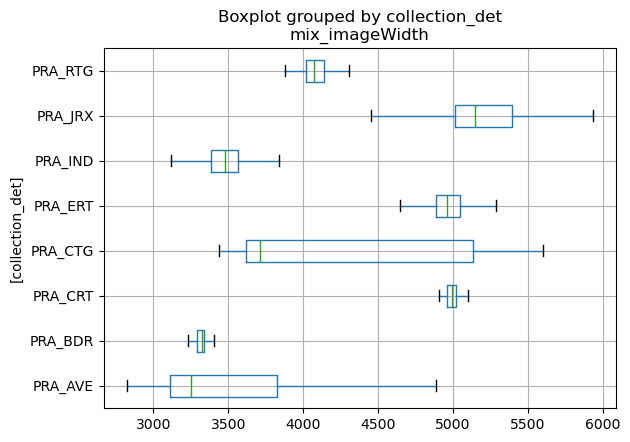

In [20]:
ax = t[['mix_imageWidth', 'collection_det']].boxplot(by='collection_det', showfliers=False, vert=False)
plt.show()

Hypothèse :
- on passe tous les fichiers presse à une largeur de 3000 px si la largeur est supérieure à cette valeur.
- point de vigilance : il y a des largeurs inférieurs à 3000 px

# on crée un échantillon d'images

In [21]:
echantillon = pd.DataFrame()
for collection in t['collection_det'].unique():
    e = t[t['collection_det'] == collection].sample(frac=0.02, random_state=2)
    echantillon = pd.concat([echantillon, e])
echantillon['size'].sum() / 1024 ** 3

np.float64(169.93652228917927)

In [22]:
len(echantillon)

6726

In [21]:
for collection in t['collection_det'].unique():
    mkdir(f"{result_folder}\{collection}")

FileExistsError: [WinError 183] Impossible de créer un fichier déjà existant: 'D:\\bnr-image-resize\\img\\PRA_AVE'

In [27]:
for img in echantillon[['path', 'name', 'collection_det']].to_dict(orient='records'):
    source = '\\\\srvbnr.ntrbx.local\\BNR\\'
    source = source + img['path'].replace('/', '\\') + '\\' + img['name']
    destination = result_folder + "\\" + img['collection'] + '\\' + img['name']
    print(source)
    #shutil.copyfile(source, destination)
    image = pyvips.Image.new_from_file(source)
    width = image.get('width')
    for px in [2000, 2500, 3000]:
        print(f"---- {px}")
        if 'resized' not in source:
            #print(file)
            if px < width:
                scale = px / width
                new_image = image.resize(scale)
                #dir_path_ = dir_path.replace('img', 'img_resized')
                #file_ = file.replace('.tif', '_resized.tif')
                #new_image.write_to_file(join(dir_path, file_), pyramid=False, tile=False, compression="deflate")
                destination_ = destination.replace('.tif', f"_resized_{str(px)}.jpeg")
                if not exists(destination_):
                    new_image.write_to_file(destination_, Q=90)
            else:
                destination_ = destination.replace('.tif', f"_notresized_{str(px)}.jpeg")
                if not exists(destination_):
                    image.write_to_file(destination_, Q=90)

\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_19140228_006.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_19040508_003.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_19130823_003.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_19061010_006.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_18960201_004.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_18901027_001.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_19111025_004.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_19090108_001.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.local\BNR\BNR_SAUV\MED\MED_PRA\PRA_AVE\PRA_AVE_18900617_004.tif
---- 2000
---- 2500
---- 3000
\\srvbnr.ntrbx.loca

# On redimensionne les images

In [59]:
#mkdir(f"img_resized")
#for collection in t['collection'].unique():
#    mkdir(f"img_resized\{collection}")

In [ ]:
for px in [1800, 2000, 2500, 3000]:
    print(px)
    for dir_path, dirs, files in walk(result_folder):
        print(f"----{dir_path}")
        for file in files:
            if 'resized' not in file:
                #print(file)
                image = pyvips.Image.new_from_file(join(dir_path, file))
                width = image.get('width')
                if px < width:
                    scale = px / width
                    new_image = image.resize(scale)
                    #dir_path_ = dir_path.replace('img', 'img_resized')
                    #file_ = file.replace('.tif', '_resized.tif')
                    #new_image.write_to_file(join(dir_path, file_), pyramid=False, tile=False, compression="deflate")
                    file_ = file.replace('.tif', f"_resized_{str(px)}.jpeg")
                    if not exists(join(dir_path, file_)):
                        new_image.write_to_file(join(dir_path, file_), Q=90)
                else:
                    file_ = file.replace('.tif', f"_notresized_{str(px)}.jpeg")
                    if not exists(join(dir_path, file_)):
                        image.write_to_file(join(dir_path, file_), Q=90)

1800
----F:\bnr-image-resize\img
----F:\bnr-image-resize\img\PRA_AVE
----F:\bnr-image-resize\img\PRA_CRT
----F:\bnr-image-resize\img\PRA_CTG
----F:\bnr-image-resize\img\PRA_ERT
----F:\bnr-image-resize\img\PRA_IND
----F:\bnr-image-resize\img\PRA_JRX
----F:\bnr-image-resize\img\PRA_RTG
----F:\bnr-image-resize\img\PRA_BDR
2000
----F:\bnr-image-resize\img
----F:\bnr-image-resize\img\PRA_AVE
----F:\bnr-image-resize\img\PRA_CRT
----F:\bnr-image-resize\img\PRA_CTG


# on récupère les tailles des nouveaux fichiers

In [23]:
newfiles = []
for dir_path, dirs, files in walk(result_folder):
    for file in files:
        if 'resized' in file:
            data = {}
            data['name'] = file
            data['size'] = getsize(join(dir_path, file))
            image = pyvips.Image.new_from_file(join(dir_path, file))
            data['width'] = image.get('width')
            data['height'] = image.get('height')
            data['resized'] = True
            newfiles.append(data)

In [24]:
newfiles_df = pd.DataFrame(newfiles)
newfiles_df['root'] = newfiles_df['name'].str[:-18]
newfiles_df

,name,size,width,height,resized,root
0,PRA_AVE_19140228_006_resized_2000.jpeg,1667948,2000,2727,True,PRA_AVE_19140228_006
1,PRA_AVE_19140228_006_resized_2500.jpeg,2334554,2500,3409,True,PRA_AVE_19140228_006
2,PRA_AVE_19140228_006_resized_3000.jpeg,3039874,3000,4091,True,PRA_AVE_19140228_006
3,PRA_AVE_19040508_003_resized_2000.jpeg,1925480,2000,2694,True,PRA_AVE_19040508_003
4,PRA_AVE_19040508_003_resized_2500.jpeg,2670143,2500,3367,True,PRA_AVE_19040508_003
...,...,...,...,...,...,...
20173,PRA_BDR_19180731_001_resized_2500.jpeg,3038888,2500,3934,True,PRA_BDR_19180731_001
20174,PRA_BDR_19180731_001_resized_3000.jpeg,4176039,3000,4721,True,PRA_BDR_19180731_001
20175,PRA_BDR_19180424_001_resized_2000.jpeg,2049711,2000,3104,True,PRA_BDR_19180424_001
20176,PRA_BDR_19180424_001_resized_2500.jpeg,3024530,2500,3880,True,PRA_BDR_19180424_001


In [29]:
echantillon2 = echantillon[['name', 'size', 'mix_imageWidth', 'mix_imageHeight', 'mix_xSamplingFrequency']]
echantillon2.columns = ['name', 'size', 'width', 'height', 'ppi']
echantillon2['resized'] = False
echantillon2['root'] = echantillon2['name'].str[:-4]
echantillon2

C:\Users\pichenotf\AppData\Local\Temp\ipykernel_940\1823383459.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  echantillon2['resized'] = False
C:\Users\pichenotf\AppData\Local\Temp\ipykernel_940\1823383459.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  echantillon2['root'] = echantillon2['name'].str[:-4]


,name,size,width,height,ppi,resized,root
254124,PRA_AVE_19140228_006.tif,20484106,3875.0,5284.0,400.0,False,PRA_AVE_19140228_006
233421,PRA_AVE_19040508_003.tif,12862099,3111.0,4190.0,400.0,False,PRA_AVE_19040508_003
252984,PRA_AVE_19130823_003.tif,21113220,3933.0,5366.0,400.0,False,PRA_AVE_19130823_003
238233,PRA_AVE_19061010_006.tif,19569868,3889.0,5030.0,400.0,False,PRA_AVE_19061010_006
221281,PRA_AVE_18960201_004.tif,12536773,3199.0,4235.0,400.0,False,PRA_AVE_18960201_004
...,...,...,...,...,...,...,...
2390337,PRA_BDR_19180227_002.tif,17449064,3328.0,5243.0,300.0,False,PRA_BDR_19180227_002
2390407,PRA_BDR_19180629_002.tif,17814171,3363.0,5297.0,300.0,False,PRA_BDR_19180629_002
2399007,PRA_BDR_19170908_001.tif,17212428,3286.0,5238.0,300.0,False,PRA_BDR_19170908_001
599309,PRA_BDR_19180731_001.tif,17440991,3329.0,5239.0,300.0,False,PRA_BDR_19180731_001


In [31]:
newfiles_df = pd.concat([newfiles_df, echantillon2])
newfiles_df

,name,size,width,height,resized,root,ppi
0,PRA_AVE_19140228_006_resized_2000.jpeg,1667948,2000.0,2727.0,True,PRA_AVE_19140228_006,NaN
1,PRA_AVE_19140228_006_resized_2500.jpeg,2334554,2500.0,3409.0,True,PRA_AVE_19140228_006,NaN
2,PRA_AVE_19140228_006_resized_3000.jpeg,3039874,3000.0,4091.0,True,PRA_AVE_19140228_006,NaN
3,PRA_AVE_19040508_003_resized_2000.jpeg,1925480,2000.0,2694.0,True,PRA_AVE_19040508_003,NaN
4,PRA_AVE_19040508_003_resized_2500.jpeg,2670143,2500.0,3367.0,True,PRA_AVE_19040508_003,NaN
...,...,...,...,...,...,...,...
2390337,PRA_BDR_19180227_002.tif,17449064,3328.0,5243.0,False,PRA_BDR_19180227_002,300.0
2390407,PRA_BDR_19180629_002.tif,17814171,3363.0,5297.0,False,PRA_BDR_19180629_002,300.0
2399007,PRA_BDR_19170908_001.tif,17212428,3286.0,5238.0,False,PRA_BDR_19170908_001,300.0
599309,PRA_BDR_19180731_001.tif,17440991,3329.0,5239.0,False,PRA_BDR_19180731_001,300.0


In [41]:
newfiles2 = []
for dir_path, dirs, files in walk(result_folder):
    for file in files:
        if 'resized' not in file:
            data = {}
            data['name'] = file
            data['size'] = getsize(join(dir_path, file))
            image = pyvips.Image.new_from_file(join(dir_path, file))
            data['width'] = image.get('width')
            data['height'] = image.get('height')
            data['resized'] = False
            newfiles2.append(data)

In [42]:
newfiles2_df = pd.DataFrame(newfiles2)
newfiles2_df['root'] = newfiles2_df['name'].str[:-4]
newfiles2_df

,name,size,width,height,resized,root
0,PRA_AVE_19030514_002.tif,12404721,3012,4116,False,PRA_AVE_19030514_002
1,PRA_AVE_18941018_003.tif,12902378,3122,4195,False,PRA_AVE_18941018_003
2,PRA_AVE_19090324_006.tif,19607162,3796,5163,False,PRA_AVE_19090324_006
3,PRA_AVE_19060925_001.tif,19525882,3815,5116,False,PRA_AVE_19060925_001
4,PRA_AVE_18920213_004.tif,12710941,3135,4212,False,PRA_AVE_18920213_004
...,...,...,...,...,...,...
787,PRA_BDR_19170707_003.tif,17415992,3316,5252,False,PRA_BDR_19170707_003
788,PRA_BDR_19180123_002.tif,17431748,3319,5252,False,PRA_BDR_19180123_002
789,PRA_BDR_19180629_002.tif,17814171,3363,5297,False,PRA_BDR_19180629_002
790,PRA_BDR_19180907_002.tif,17672059,3359,5261,False,PRA_BDR_19180907_002


In [43]:
newfiles_df = pd.concat([newfiles_df, newfiles2_df])
newfiles_df

,name,size,width,height,resized,root
0,PRA_AVE_19030514_002_resized_1800.jpeg,1822121,1800,2460,True,PRA_AVE_19030514_002
1,PRA_AVE_18941018_003_resized_1800.jpeg,1791043,1800,2419,True,PRA_AVE_18941018_003
2,PRA_AVE_19090324_006_resized_1800.jpeg,1533433,1800,2448,True,PRA_AVE_19090324_006
3,PRA_AVE_19060925_001_resized_1800.jpeg,1567622,1800,2414,True,PRA_AVE_19060925_001
4,PRA_AVE_18920213_004_resized_1800.jpeg,1480795,1800,2418,True,PRA_AVE_18920213_004
...,...,...,...,...,...,...
787,PRA_BDR_19170707_003.tif,17415992,3316,5252,False,PRA_BDR_19170707_003
788,PRA_BDR_19180123_002.tif,17431748,3319,5252,False,PRA_BDR_19180123_002
789,PRA_BDR_19180629_002.tif,17814171,3363,5297,False,PRA_BDR_19180629_002
790,PRA_BDR_19180907_002.tif,17672059,3359,5261,False,PRA_BDR_19180907_002


In [33]:
newfiles_df['resolution'] = newfiles_df['width'] * newfiles_df['width']
newfiles_df.loc[newfiles_df['width'] == 1800, 'version'] = 'w1800'
newfiles_df.loc[newfiles_df['width'] == 2000, 'version'] = 'w2000'
newfiles_df.loc[newfiles_df['width'] == 2500, 'version'] = 'w2500'
newfiles_df.loc[newfiles_df['width'] == 3000, 'version'] = 'w3000'
newfiles_df.loc[newfiles_df['resized'] == False, 'version'] = 'original'
newfiles_df = newfiles_df[~newfiles_df['version'].isna()]

In [35]:
newfiles_df['version'].value_counts(dropna=False)

version
w2000       6726
w2500       6726
original    6726
w3000       6691
Name: count, dtype: int64

ppi
NaN      20143
400.0     6631
300.0       95
Name: count, dtype: int64

In [42]:
res = pd.pivot_table(newfiles_df, index='root', columns='version', values=['size', 'width', 'height', 'ppi'], aggfunc='sum').reset_index()
res

root   height                              ppi        \
version                       original   w2000   w2500   w3000 original w2000   
0        PRA_AVE_18881009_001   4216.0  2747.0  3434.0  4121.0    400.0   0.0   
1        PRA_AVE_18881012_001   4253.0  2755.0  3443.0  4132.0    400.0   0.0   
2        PRA_AVE_18881013_004   4235.0  2722.0  3402.0  4083.0    400.0   0.0   
3        PRA_AVE_18881014_003   4265.0  2650.0  3312.0  3975.0    400.0   0.0   
4        PRA_AVE_18881017_002   4224.0  2650.0  3312.0  3975.0    400.0   0.0   
...                       ...      ...     ...     ...     ...      ...   ...   
6721     PRA_RTG_18911004_001   5237.0  2470.0  3087.0  3705.0    400.0   0.0   
6722     PRA_RTG_18911004_002   5087.0  2554.0  3193.0  3832.0    400.0   0.0   
6723     PRA_RTG_18911024_001   5103.0  2479.0  3099.0  3718.0    400.0   0.0   
6724     PRA_RTG_18911025_004   5179.0  2497.0  3121.0  3745.0    400.0   0.0   
6725     PRA_RTG_18911126_004   5249.0  2477.0  3096.0  3716.0    400.0   0.0   

                           size                                     width  \
version w2500 w3000    original      w2000      w2500      w3000 original   
0         0.0   0.0  12520441.0  2081717.0  2862027.0  3673979.0   3069.0   
1         0.0   0.0  12630322.0  2072561.0  2854232.0  3669640.0   3088.0   
2         0.0   0.0  11656800.0  1801362.0  2485805.0  3204562.0   3112.0   
3         0.0   0.0  11607493.0  1920041.0  2657627.0  3405941.0   3219.0   
4         0.0   0.0  12842953.0  1979872.0  2743891.0  3531608.0   3188.0   
...       ...   ...         ...        ...        ...        ...      ...   
6721      0.0   0.0  22220747.0  1738071.0  2426687.0  3128338.0   4241.0   
6722      0.0   0.0  20269815.0  1930785.0  2681009.0  3447180.0   3983.0   
6723      0.0   0.0  21019409.0  1787193.0  2478994.0  3186530.0   4117.0   
6724      0.0   0.0  21498181.0  1526273.0  2122579.0  2747754.0   4149.0   
6725      0.0   0.0  22255916.0  1640943.0  2296423.0  2992582.0   4238.0   

                                 
version   w2000   w2500   w3000  
0        2000.0  2500.0  3000.0  
1        2000.0  2500.0  3000.0  
2        2000.0  2500.0  3000.0  
3        2000.0  2500.0  3000.0  
4        2000.0  2500.0  3000.0  
...         ...     ...     ...  
6721     2000.0  2500.0  3000.0  
6722     2000.0  2500.0  3000.0  
6723     2000.0  2500.0  3000.0  
6724     2000.0  2500.0  3000.0  
6725     2000.0  2500.0  3000.0  

[6726 rows x 17 columns]

In [50]:
for w in ['w2000', 'w2500', 'w3000']:
    res.loc['ppi'][w] = round(res['width'][w] / res['width']['original'] * res['ppi']['original'])
    print(round(res['width'][w] / res['width']['original'] * res['ppi']['original']))
res

0       261.0
1       259.0
2       257.0
3       249.0
4       251.0
        ...  
6721    189.0
6722    201.0
6723    194.0
6724    193.0
6725    189.0
Length: 6726, dtype: float64
0       326.0
1       324.0
2       321.0
3       311.0
4       314.0
        ...  
6721    236.0
6722    251.0
6723    243.0
6724    241.0
6725    236.0
Length: 6726, dtype: float64
0       391.0
1       389.0
2       386.0
3       373.0
4       376.0
        ...  
6721    283.0
6722    301.0
6723    291.0
6724    289.0
6725    283.0
Length: 6726, dtype: float64


C:\Users\pichenotf\AppData\Local\Temp\ipykernel_940\3948971775.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res['ppi'][w] = round(res['width'][w] / res['width']['original'] * res['ppi']['original'])


root   height                              ppi        \
version                       original   w2000   w2500   w3000 original w2000   
0        PRA_AVE_18881009_001   4216.0  2747.0  3434.0  4121.0    400.0   0.0   
1        PRA_AVE_18881012_001   4253.0  2755.0  3443.0  4132.0    400.0   0.0   
2        PRA_AVE_18881013_004   4235.0  2722.0  3402.0  4083.0    400.0   0.0   
3        PRA_AVE_18881014_003   4265.0  2650.0  3312.0  3975.0    400.0   0.0   
4        PRA_AVE_18881017_002   4224.0  2650.0  3312.0  3975.0    400.0   0.0   
...                       ...      ...     ...     ...     ...      ...   ...   
6721     PRA_RTG_18911004_001   5237.0  2470.0  3087.0  3705.0    400.0   0.0   
6722     PRA_RTG_18911004_002   5087.0  2554.0  3193.0  3832.0    400.0   0.0   
6723     PRA_RTG_18911024_001   5103.0  2479.0  3099.0  3718.0    400.0   0.0   
6724     PRA_RTG_18911025_004   5179.0  2497.0  3121.0  3745.0    400.0   0.0   
6725     PRA_RTG_18911126_004   5249.0  2477.0  3096.0  3716.0    400.0   0.0   

                           size                                     width  \
version w2500 w3000    original      w2000      w2500      w3000 original   
0         0.0   0.0  12520441.0  2081717.0  2862027.0  3673979.0   3069.0   
1         0.0   0.0  12630322.0  2072561.0  2854232.0  3669640.0   3088.0   
2         0.0   0.0  11656800.0  1801362.0  2485805.0  3204562.0   3112.0   
3         0.0   0.0  11607493.0  1920041.0  2657627.0  3405941.0   3219.0   
4         0.0   0.0  12842953.0  1979872.0  2743891.0  3531608.0   3188.0   
...       ...   ...         ...        ...        ...        ...      ...   
6721      0.0   0.0  22220747.0  1738071.0  2426687.0  3128338.0   4241.0   
6722      0.0   0.0  20269815.0  1930785.0  2681009.0  3447180.0   3983.0   
6723      0.0   0.0  21019409.0  1787193.0  2478994.0  3186530.0   4117.0   
6724      0.0   0.0  21498181.0  1526273.0  2122579.0  2747754.0   4149.0   
6725      0.0   0.0  22255916.0  1640943.0  2296423.0  2992582.0   4238.0   

                                 
version   w2000   w2500   w3000  
0        2000.0  2500.0  3000.0  
1        2000.0  2500.0  3000.0  
2        2000.0  2500.0  3000.0  
3        2000.0  2500.0  3000.0  
4        2000.0  2500.0  3000.0  
...         ...     ...     ...  
6721     2000.0  2500.0  3000.0  
6722     2000.0  2500.0  3000.0  
6723     2000.0  2500.0  3000.0  
6724     2000.0  2500.0  3000.0  
6725     2000.0  2500.0  3000.0  

[6726 rows x 17 columns]

In [75]:
pd.pivot_table(newfiles_df, index='root', columns='version', values=['size', 'width', 'height'], aggfunc='sum').reset_index().to_excel("tmp.xlsx")

# on essaie de prédire la taille des fichiers selon leur taille de départ

In [76]:
data = pd.read_excel("tmp.xlsx")
data

,file,height_original,size_original,size_w1800,size_w2000,size_w2500,size_w3000,width_original
0,PRA_AVE_18890607_002,4502,13732001,1581668,1858326,2584661,3358489.0,3393
1,PRA_AVE_18900218_004,4246,11770193,1435699,1684369,2334517,3018226.0,3139
2,PRA_AVE_18900521_004,4198,12666193,1596579,1868429,2590835,3349506.0,3105
3,PRA_AVE_18901026_004,4284,11911366,1568922,1839570,2540487,3279110.0,3106
4,PRA_AVE_18901030_003,4313,10633160,1540709,1808837,2504669,3208417.0,3086
...,...,...,...,...,...,...,...,...
787,PRA_RTG_18911211_002,5113,20562594,1669754,1961538,2726786,3525276.0,4020
788,PRA_RTG_18911212_002,5114,20551272,1613894,1895952,2642216,3418051.0,4017
789,PRA_RTG_18911213_003,5119,21126265,1581971,1862258,2594103,3355782.0,4125
790,PRA_RTG_18911215_002,5131,21103955,1656683,1952316,2722091,3531149.0,4111


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

## width 1800

In [110]:
x = pd.DataFrame(np.c_[data['size_original'], data['height_original'], data['width_original']], columns = ['size_original','height_original', 'width_original'])
scale = StandardScaler()
x = scale.fit_transform(x)
y = data['size_w1800'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_width_1800 = LinearRegression()
model_width_1800.fit(X_train, y_train)

y_pred = model_width_1800.predict(X_test)

r2_score = model_width_1800.score(x,y)
mae = mean_absolute_error(y, model_width_1800.predict(x))
print(f'Coefficient R² = {r2_score:.2f}')
print(f'Mean absolute error = {mae:.2f}')

Coefficient R² = 0.63
Mean absolute error = 116574.69


## width 2000

In [111]:
x = pd.DataFrame(np.c_[data['size_original'], data['height_original'], data['width_original']], columns = ['size_original','height_original', 'width_original'])
scale = StandardScaler()
x = scale.fit_transform(x)
y = data['size_w2000'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_width_2000 = LinearRegression()
model_width_2000.fit(X_train, y_train)

y_pred = model_width_2000.predict(X_test)

r2_score = model_width_2000.score(x,y)
mae = mean_absolute_error(y, model_width_2000.predict(x))
print(f'Coefficient R² = {r2_score:.2f}')
print(f'Mean absolute error = {mae:.2f}')

Coefficient R² = 0.63
Mean absolute error = 143192.95


## width 2500

In [112]:
x = pd.DataFrame(np.c_[data['size_original'], data['height_original'], data['width_original']], columns = ['size_original','height_original', 'width_original'])
scale = StandardScaler()
x = scale.fit_transform(x)
y = data['size_w2500'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_width_2000 = LinearRegression()
model_width_2000.fit(X_train, y_train)

y_pred = model_width_2000.predict(X_test)

r2_score = model_width_2000.score(x,y)
mae = mean_absolute_error(y, model_width_2000.predict(x))
print(f'Coefficient R² = {r2_score:.2f}')
print(f'Mean absolute error = {mae:.2f}')

Coefficient R² = 0.61
Mean absolute error = 216799.30


## width 3000

In [113]:
data = data[~data['size_w3000'].isna()]
x = pd.DataFrame(np.c_[data['size_original'], data['height_original'], data['width_original']], columns = ['size_original','height_original', 'width_original'])
scale = StandardScaler()
x = scale.fit_transform(x)
y = data['size_w3000'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model_width_3000 = LinearRegression()
model_width_3000.fit(X_train, y_train)

y_pred = model_width_3000.predict(X_test)

r2_score = model_width_3000.score(x,y)
mae = mean_absolute_error(y, model_width_3000.predict(x))
print(f'Coefficient R² = {r2_score:.2f}')
print(f'Mean absolute error = {mae:.2f}')

Coefficient R² = 0.67
Mean absolute error = 293908.72


## on applique les prédictions aux documents tiff presse

In [128]:
x = pd.DataFrame(np.c_[t['size'], t['mix_imageHeight'], t['mix_imageWidth']], columns = ['size','mix_imageHeight', 'mix_imageWidth'])
scale = StandardScaler()
x = scale.fit_transform(x)
t['size_width_1800'] = model_width_1800.predict(x)
t['size_width_2000'] = model_width_2000.predict(x)
t['size_width_2500'] = model_width_2500.predict(x)
t['size_width_3000'] = model_width_3000.predict(x)

C:\Users\pichenotf\AppData\Local\Temp\ipykernel_9984\1363978591.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t['size_width_1800'] = model_width_1800.predict(x)
C:\Users\pichenotf\AppData\Local\Temp\ipykernel_9984\1363978591.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t['size_width_2000'] = model_width_2000.predict(x)
C:\Users\pichenotf\.conda\envs\ds\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with featu

In [137]:
t[['size', 'size_width_1800', 'size_width_2000', 'size_width_2500', 'size_width_3000']].sum() / 1024 ** 4

size               8.307722
size_width_1800    0.488905
size_width_2000    0.809232
size_width_2500    0.910581
size_width_3000    1.062718
dtype: float64

In [139]:
x = pd.DataFrame(np.c_[data['size_original'], data['height_original'], data['width_original']], columns = ['size_original','height_original', 'width_original'])
scale = StandardScaler()
x = scale.fit_transform(x)
data['size_w1800_predicted'] = model_width_1800.predict(x)
data['size_w2000_predicted'] = model_width_2000.predict(x)
data['size_w2500_predicted'] = model_width_2500.predict(x)
data['size_w3000_predicted'] = model_width_3000.predict(x)

C:\Users\pichenotf\.conda\envs\ds\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [140]:
data

,file,height_original,size_original,size_w1800,size_w2000,size_w2500,size_w3000,width_original,size_w1800_predicted,size_w2000_predicted,size_w2500_predicted,size_w3000_predicted
0,PRA_AVE_18890607_002,4502,13732001,1581668,1858326,2584661,3358489.0,3393,1.534202e+06,2.508279e+06,2.977789e+06,3.237416e+06
1,PRA_AVE_18900218_004,4246,11770193,1435699,1684369,2334517,3018226.0,3139,1.548008e+06,2.529413e+06,2.977920e+06,3.262380e+06
2,PRA_AVE_18900521_004,4198,12666193,1596579,1868429,2590835,3349506.0,3105,1.573059e+06,2.573213e+06,2.977934e+06,3.321718e+06
3,PRA_AVE_18901026_004,4284,11911366,1568922,1839570,2540487,3279110.0,3106,1.566809e+06,2.564941e+06,2.977954e+06,3.317986e+06
4,PRA_AVE_18901030_003,4313,10633160,1540709,1808837,2504669,3208417.0,3086,1.549673e+06,2.535728e+06,2.977977e+06,3.281316e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
787,PRA_RTG_18911211_002,5113,20562594,1669754,1961538,2726786,3525276.0,4020,1.540245e+06,2.527054e+06,2.977463e+06,3.273014e+06
788,PRA_RTG_18911212_002,5114,20551272,1613894,1895952,2642216,3418051.0,4017,1.541143e+06,2.528752e+06,2.977465e+06,3.275703e+06
789,PRA_RTG_18911213_003,5119,21126265,1581971,1862258,2594103,3355782.0,4125,1.517307e+06,2.484169e+06,2.977384e+06,3.205798e+06
790,PRA_RTG_18911215_002,5131,21103955,1656683,1952316,2722091,3531149.0,4111,1.523028e+06,2.495075e+06,2.977398e+06,3.223186e+06


In [142]:
data[['size_original',
      'size_w1800', 'size_w1800_predicted',
      'size_w2000', 'size_w2000_predicted',
      'size_w2500', 'size_w2500_predicted',
      'size_w3000', 'size_w3000_predicted']].sum() / 1024 ** 2

size_original           17823.949405
size_w1800               1200.121119
size_w1800_predicted     1204.411392
size_w2000               1415.041193
size_w2000_predicted     1993.533791
size_w2500               1985.969911
size_w2500_predicted     2243.206296
size_w3000               2606.086570
size_w3000_predicted     2617.993804
dtype: float64

In [27]:
echantillon.columns

Index(['name', 'path', 'size', 'last_content_modification_date',
       'last_metadata_modification_date', 'checksum_md5', 'uuid', 'extension',
       'file_type', 'source2s3', 'conservation_statut', 's3_uploaded_date',
       's3_uploaded', 's3_key', 'finding_aid', 'unitid', 'osiros_id',
       'mix_objectIdentifierValue', 'mix_fileSize', 'mix_dateTimeCreated',
       'mix_formatName', 'mix_byteOrder', 'mix_compressionScheme',
       'mix_imageWidth', 'mix_imageHeight', 'mix_xSamplingFrequency',
       'mix_ySamplingFrequency', 'mix_samplingFrequencyUnit', 'mix_colorSpace',
       'mix_scanningSoftwareName', 'mix_formatVersion', 'publication_statut',
       'collection_code', 'oai_set', 'collection', 'nb', 'collection_det',
       'resolution'],
      dtype='object')